In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


In [2]:
df = pd.read_csv('heart.csv')

print("Shape of the dataset:", df.shape)
print("\nData Types and Non-Null Counts:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())


df.head()

Shape of the dataset: (1025, 14)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
o

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


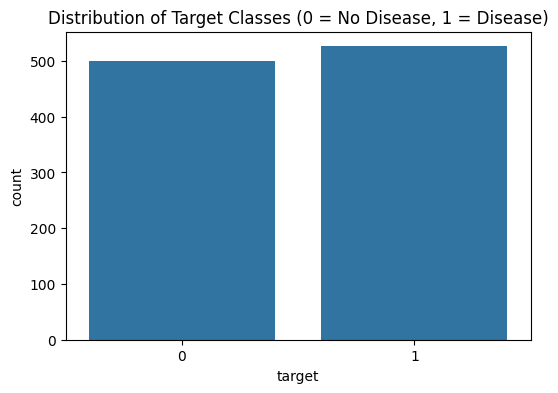

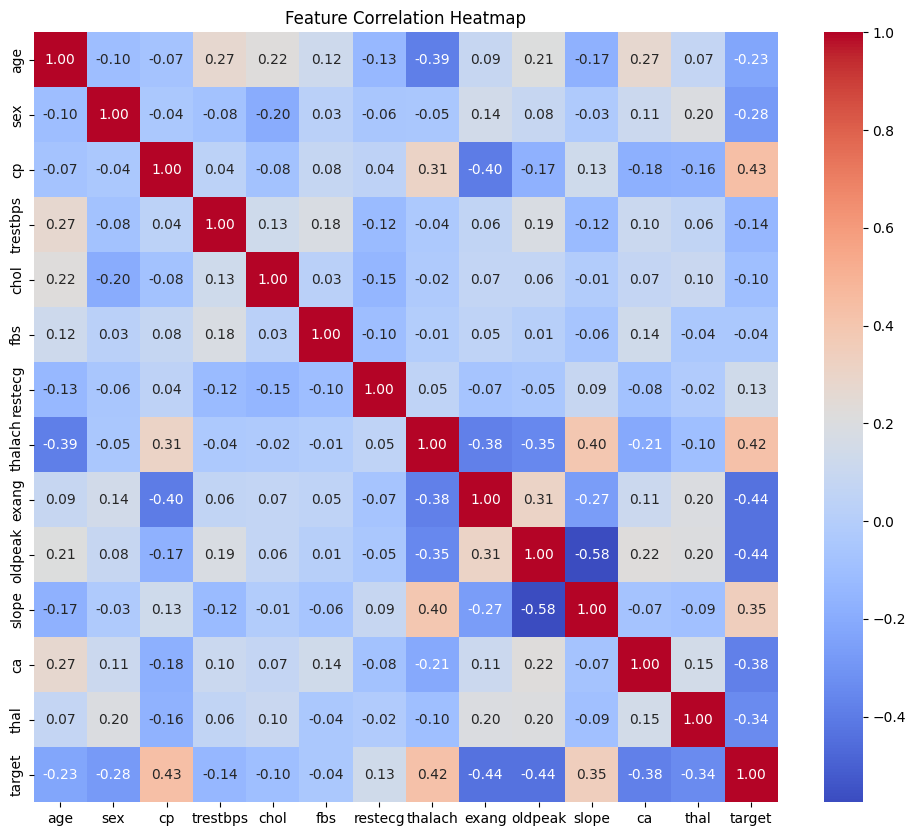

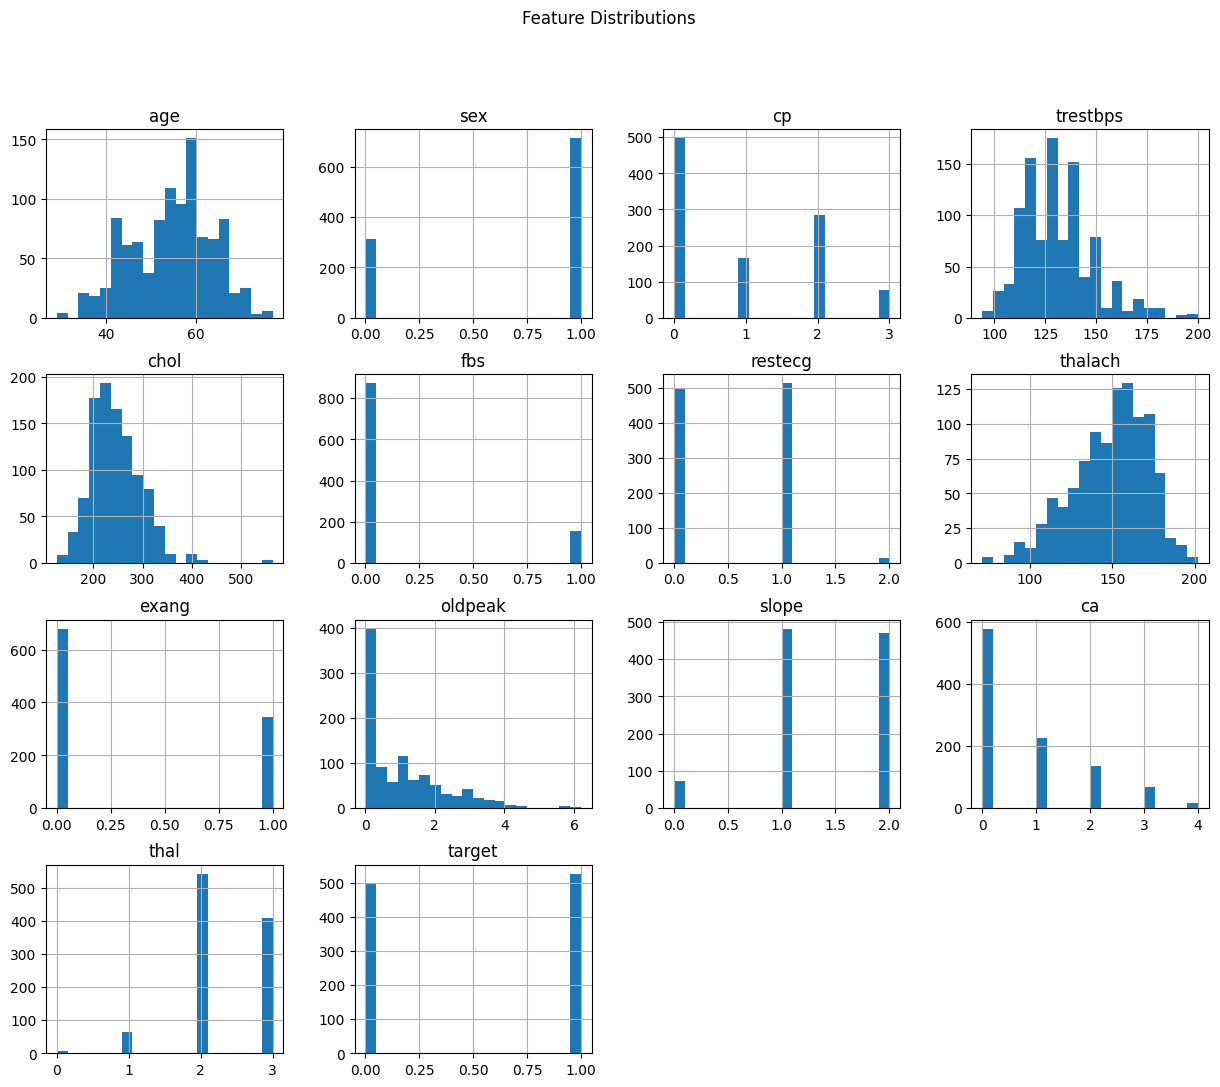

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title("Distribution of Target Classes (0 = No Disease, 1 = Disease)")
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

In [ ]:
df.fillna(df.median(), inplace=True)

X = df.drop('target', axis=1).values
y = df['target'].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features manually or using numpy
def standardize(X_train, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    
    # Avoid division by zero
    std[std == 0] = 1e-8
    
    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std
    return X_train_scaled, X_test_scaled

X_train_scaled, X_test_scaled = standardize(X_train, X_test)

X_train_scaled = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print("X_train scaled shape:", X_train_scaled.shape)

X_train scaled shape: (820, 14)


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    m = y.shape[0]
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return loss

def train_logistic_regression(X, y, learning_rate=0.01, iterations=1000):
    m, n = X.shape
    weights = np.zeros((n, 1))
    losses = []
    
    for i in range(iterations):
        z = np.dot(X, weights)
        y_pred = sigmoid(z)
        
        loss = compute_loss(y, y_pred)
        losses.append(loss)
        
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        
        weights -= learning_rate * dw
        
    return weights, losses


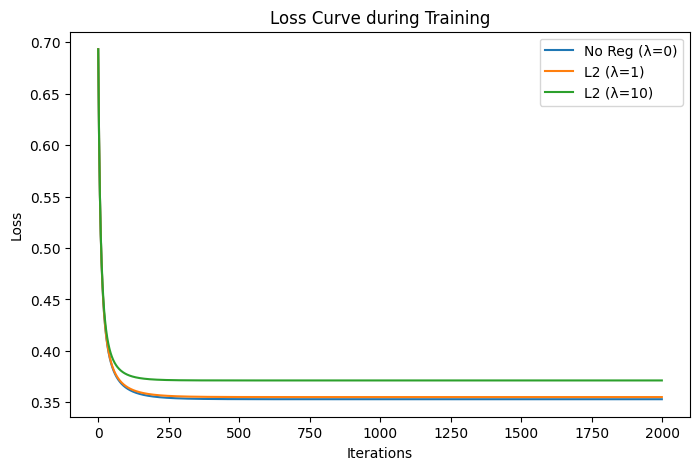

In [ ]:
# Gradient Descent Optimization with L2 Regularization
def train_logistic_regression_l2(X, y, learning_rate=0.01, iterations=1000, lambda_=1.0):
    m, n = X.shape
    weights = np.zeros((n, 1))
    losses = []
    
    for i in range(iterations):
        z = np.dot(X, weights)
        y_pred = sigmoid(z)
        
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        cross_entropy = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        l2_penalty = (lambda_ / (2*m)) * np.sum(weights[1:]**2)
        loss = cross_entropy + l2_penalty
        losses.append(loss)
        
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        
        dw[1:] += (lambda_ / m) * weights[1:]
        
        weights -= learning_rate * dw
        
    return weights, losses

# Train models with different lambda values
learning_rate = 0.1
iterations = 2000

# 1. Non-regularized
w_none, loss_none = train_logistic_regression_l2(X_train_scaled, y_train, learning_rate, iterations, lambda_=0)
# 2. lambda = 1
w_l1, loss_l1 = train_logistic_regression_l2(X_train_scaled, y_train, learning_rate, iterations, lambda_=1)
# 3. lambda = 10
w_l10, loss_l10 = train_logistic_regression_l2(X_train_scaled, y_train, learning_rate, iterations, lambda_=10)

plt.figure(figsize=(8, 5))
plt.plot(loss_none, label='No Reg (λ=0)')
plt.plot(loss_l1, label='L2 (λ=1)')
plt.plot(loss_l10, label='L2 (λ=10)')
plt.title('Loss Curve during Training')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()


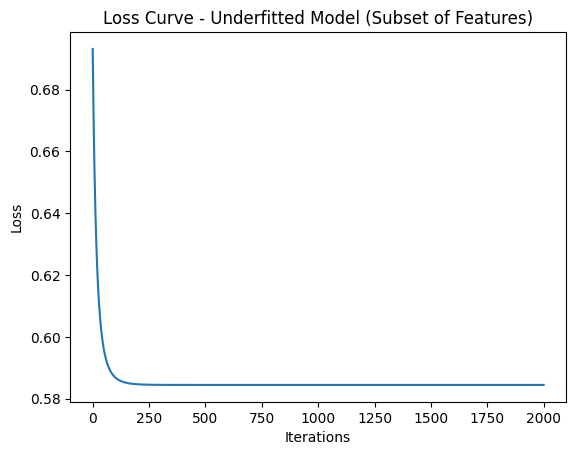

In [ ]:
# Select subset of features (e.g., age, chol, thalach)
# Column indices in original dataset: age=0, chol=4, thalach=7
features_subset = ['age', 'chol', 'thalach']
X_sub = df[features_subset].values

X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y, test_size=0.2, random_state=42, stratify=y)
X_train_sub_scaled, X_test_sub_scaled = standardize(X_train_sub, X_test_sub)

X_train_sub_scaled = np.c_[np.ones((X_train_sub_scaled.shape[0], 1)), X_train_sub_scaled]
X_test_sub_scaled = np.c_[np.ones((X_test_sub_scaled.shape[0], 1)), X_test_sub_scaled]

w_sub, loss_sub = train_logistic_regression(X_train_sub_scaled, y_train_sub, learning_rate=0.1, iterations=2000)

plt.plot(loss_sub)
plt.title('Loss Curve - Underfitted Model (Subset of Features)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.show()


Evaluating on Testing Set:

--- Evaluation for Full Model (No Reg) ---
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1-Score : 0.8312
ROC-AUC  : 0.9296

--- Evaluation for Full Model (λ=1) ---
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1-Score : 0.8312
ROC-AUC  : 0.9298

--- Evaluation for Full Model (λ=10) ---
Accuracy : 0.8146
Precision: 0.7638
Recall   : 0.9238
F1-Score : 0.8362
ROC-AUC  : 0.9295

--- Evaluation for Underfitted Model (Subset Features) ---
Accuracy : 0.6780
Precision: 0.6696
Recall   : 0.7333
F1-Score : 0.7000
ROC-AUC  : 0.7411



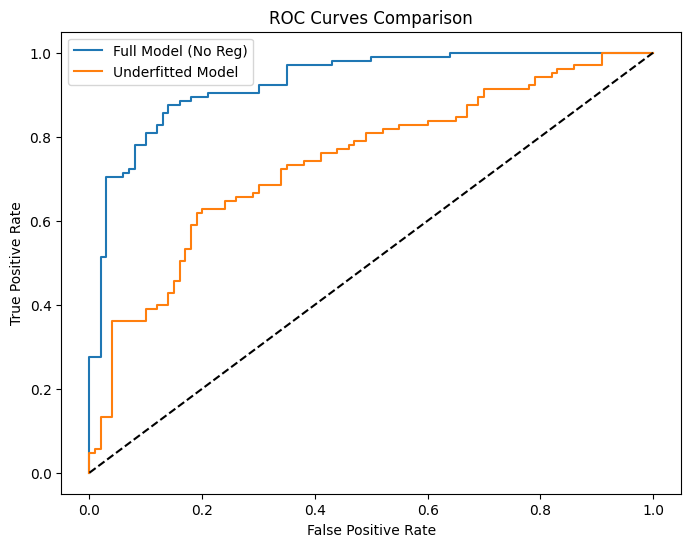

In [8]:
def evaluate_model(X, y, weights, model_name):
    y_pred_prob = sigmoid(np.dot(X, weights))
    y_pred_class = (y_pred_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y, y_pred_class)
    prec = precision_score(y, y_pred_class)
    rec = recall_score(y, y_pred_class)
    f1 = f1_score(y, y_pred_class)
    auc = roc_auc_score(y, y_pred_prob)
    
    print(f"--- Evaluation for {model_name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}\n")
    return y_pred_prob

print("Evaluating on Testing Set:\n")
prob_none = evaluate_model(X_test_scaled, y_test, w_none, "Full Model (No Reg)")
prob_l1 = evaluate_model(X_test_scaled, y_test, w_l1, "Full Model (λ=1)")
prob_l10 = evaluate_model(X_test_scaled, y_test, w_l10, "Full Model (λ=10)")
prob_sub = evaluate_model(X_test_sub_scaled, y_test_sub, w_sub, "Underfitted Model (Subset Features)")

# ROC Curves
fpr_none, tpr_none, _ = roc_curve(y_test, prob_none)
fpr_sub, tpr_sub, _ = roc_curve(y_test_sub, prob_sub)

plt.figure(figsize=(8, 6))
plt.plot(fpr_none, tpr_none, label='Full Model (No Reg)')
plt.plot(fpr_sub, tpr_sub, label='Underfitted Model')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()
